Step 1 complete: Dataset downloaded.
Performing word segmentation...
Step 2 complete: Segmentation done.
Computing TF-IDF...
Step 3 complete: TF-IDF matrix built.
Calculating term frequency...
TF calculation done.
Calculating total scores...
Scores calculated.
Plotting charts...


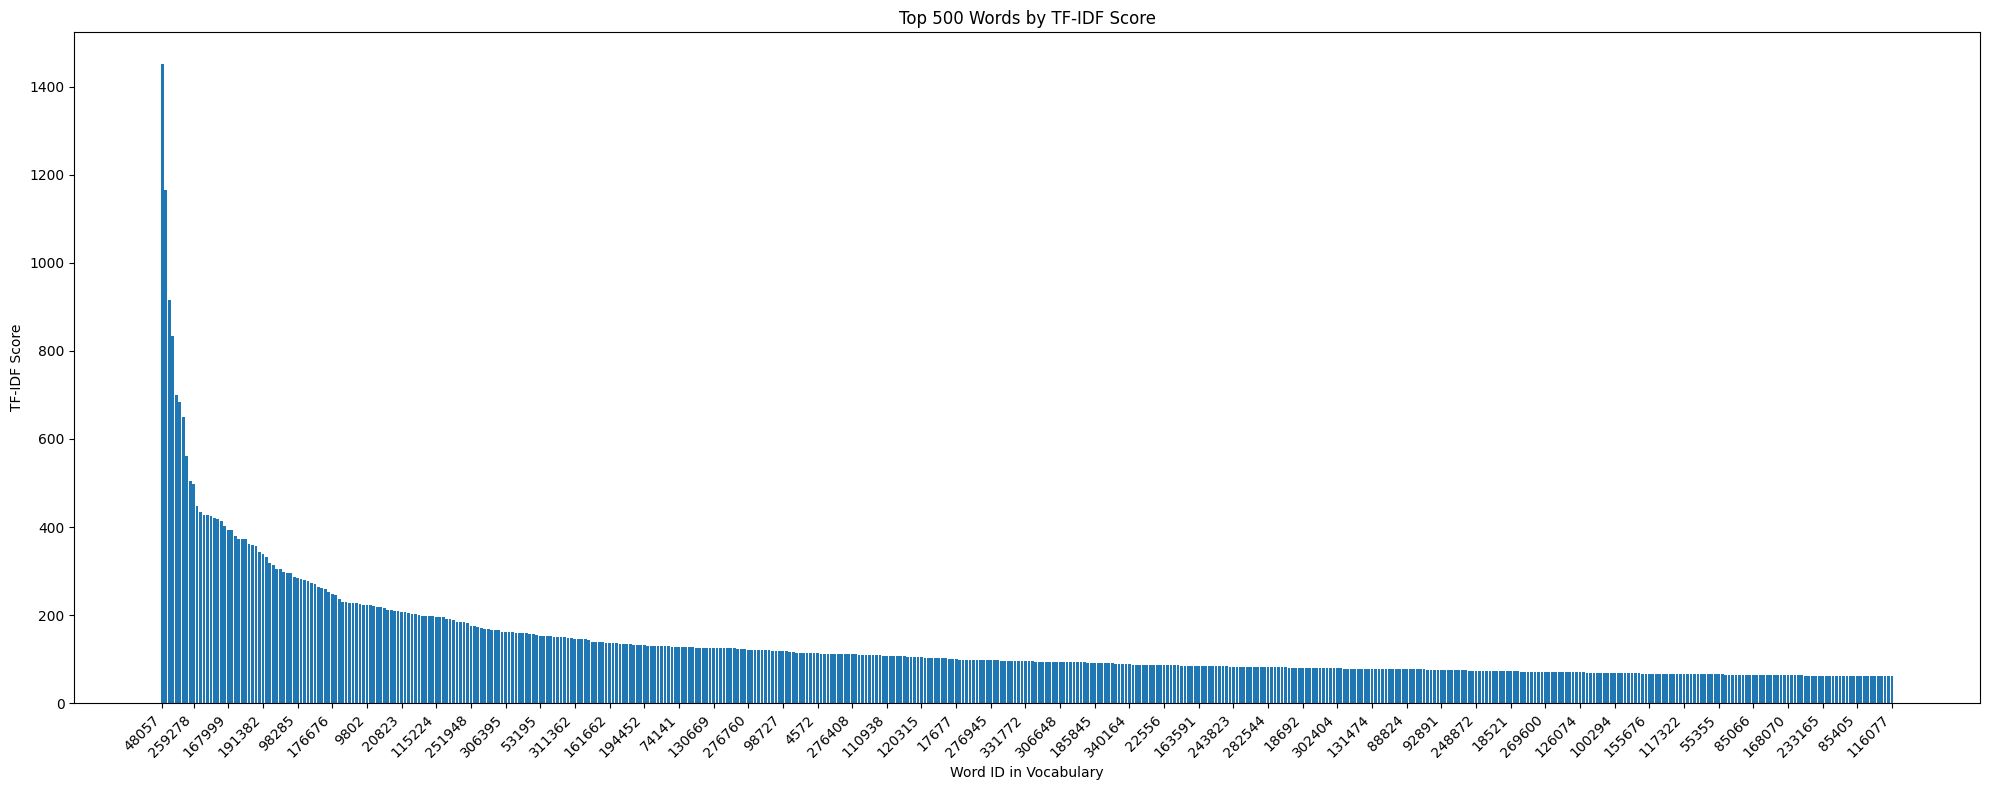

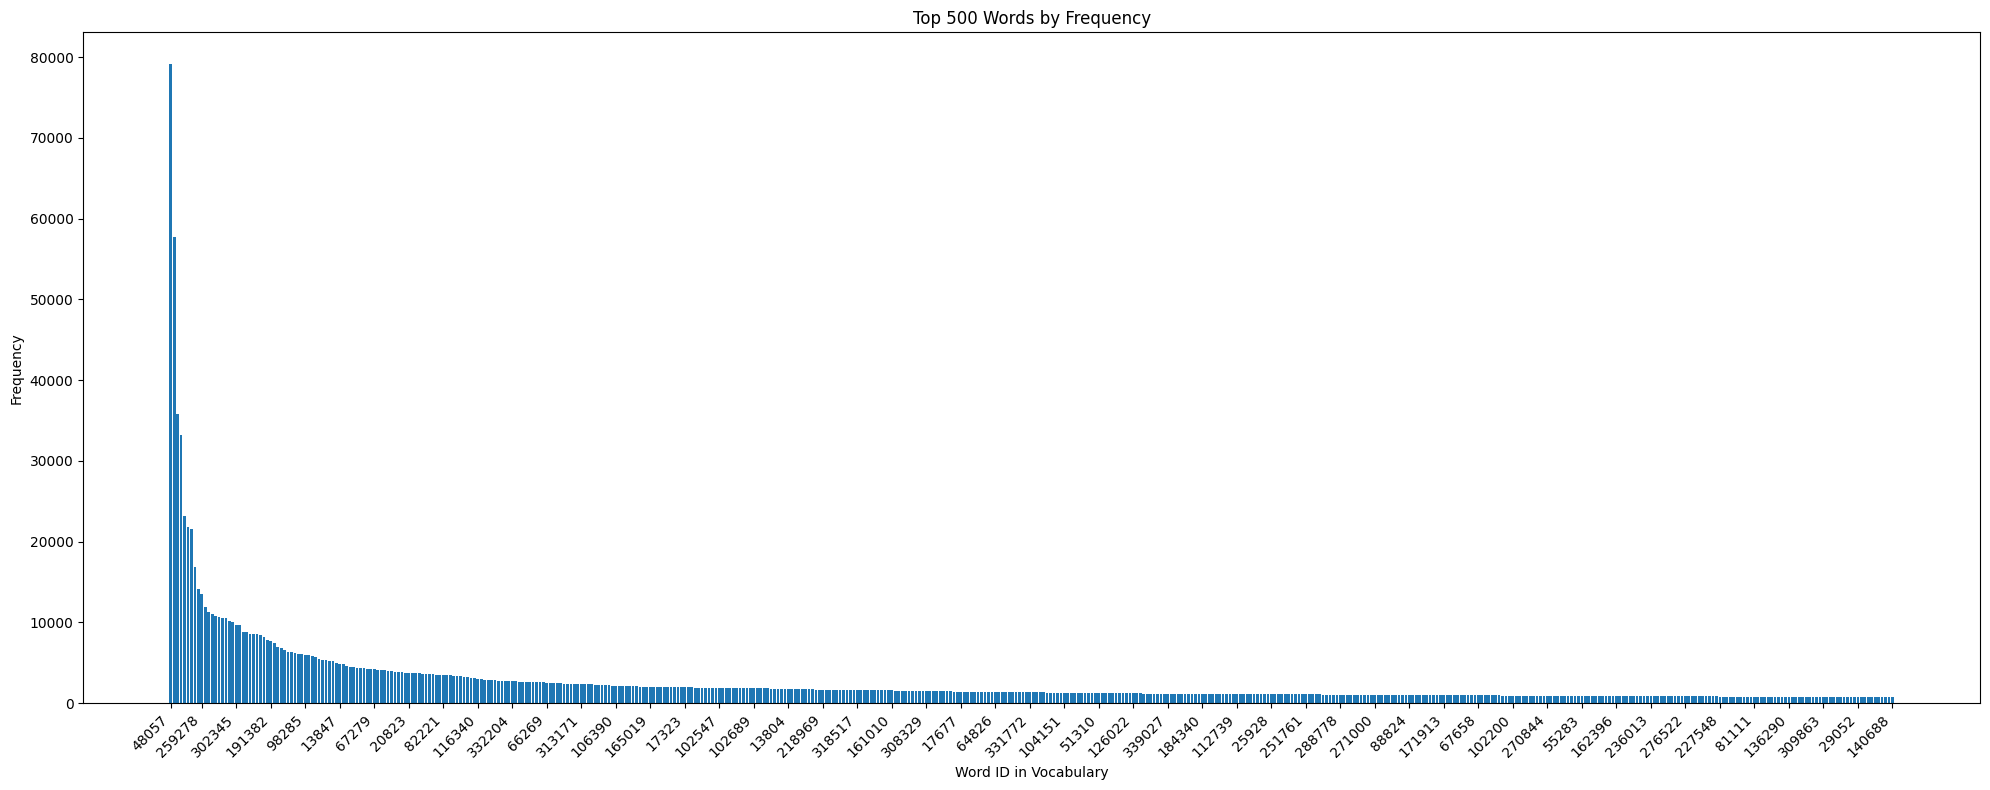

Charts saved. Total 2 charts generated.


In [7]:
import os
import urllib.request
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

# 如果在 Colab 環境中，設定支援中文字體避免亂碼
plt.rcParams['axes.unicode_minus'] = False

# Step 1: Download dataset
print("Downloading dataset...")
url = "https://github.com/cjwu/cjwu.github.io/raw/master/courses/nlp/hw1-dataset.txt"
dataset_path = "hw1-dataset.txt"
if not os.path.exists(dataset_path):
    urllib.request.urlretrieve(url, dataset_path)
print("Step 1 complete: Dataset downloaded.")

# Step 2: 讀取語料庫，10行算一個文章，並進行分詞
print("Performing word segmentation...")
documents = []
with open(dataset_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    doc_lines = []
    for i, line in enumerate(lines):
        line = line.strip()
        if line:
            doc_lines.append(line)
        # 10行算一個文章
        if (i + 1) % 10 == 0:
            if doc_lines:
                documents.append(" ".join(doc_lines))
                doc_lines = []
    # 處理最後剩餘不足10行的部分
    if doc_lines:
        documents.append(" ".join(doc_lines))

# 進行 Jieba 斷詞
segmented_docs = []
for doc in documents:
    seg_list = jieba.lcut(doc)
    # 過濾空白與換行符號
    seg_list = [word for word in seg_list if word.strip()]
    segmented_docs.append(" ".join(seg_list))
print("Step 2 complete: Segmentation done.")

# Step 3: Computing TF-IDF
print("Computing TF-IDF...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(segmented_docs)
feature_names = tfidf_vectorizer.get_feature_names_out()
print("Step 3 complete: TF-IDF matrix built.")

# Step 4: Calculating term frequency
print("Calculating term frequency...")
count_vectorizer = CountVectorizer()
tf_matrix = count_vectorizer.fit_transform(segmented_docs)
print("TF calculation done.")

# Step 5: Calculating total TF-IDF and TF scores
print("Calculating total scores...")
tfidf_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
tf_scores = np.asarray(tf_matrix.sum(axis=0)).ravel()

# 建立字詞到編號的對應表 (Word ID in Vocabulary)
word_ids = {word: idx for idx, word in enumerate(feature_names)}

tfidf_dict = {feature_names[i]: tfidf_scores[i] for i in range(len(feature_names))}
tf_dict = {feature_names[i]: tf_scores[i] for i in range(len(feature_names))}
print("Scores calculated.")

# Step 6: 統計前500個高頻和TF-IDF權重高的字詞
top_500_tfidf = sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:500]
top_500_tf = sorted(tf_dict.items(), key=lambda x: x[1], reverse=True)[:500]

# 定義畫圖函數
def plot_top_words(top_data, title, ylabel, fig_num):
    words = [item[0] for item in top_data]
    y_values = [item[1] for item in top_data]

    # 這裡保留原來的字詞編號 (HW2 規定 x軸: 字詞編號)
    actual_ids = [str(word_ids[w]) for w in words]

    bar_positions = np.arange(len(words))

    plt.figure(figsize=(20, 8))
    plt.bar(bar_positions, y_values)

    # 抓取 Top 1, 10, 20, 30... 的正確索引 (即 index 0, 9, 19, 29...)
    tick_positions = [0] + list(range(9, len(words), 10))

    # 【嚴格審計修正】: 將原來的「字詞編號」從陣列中抽出來顯示，取代原本寫死的字串
    tick_labels = [actual_ids[i] for i in tick_positions]

    # 將原來的標籤套用至圖表 X 軸
    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=10, ha='right')
    plt.title(title)
    plt.xlabel("Word ID in Vocabulary")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(f'fig{fig_num}.png')
    plt.show()

# Step 7: Plotting charts
print("Plotting charts...")
# fig#1: TF-IDF權重
plot_top_words(top_500_tfidf, 'Top 500 Words by TF-IDF Score', 'TF-IDF Score', 1)
# fig#2: 出現頻率
plot_top_words(top_500_tf, 'Top 500 Words by Frequency', 'Frequency', 2)
print("Charts saved. Total 2 charts generated.")